# 04 — Validation: Model Perencana Makan

**Validasi:**
1. Constraint kalori ±15% dari target
2. Budget compliance (≤ 50,000 IDR/hari)
3. Macro balance (protein ≥ 15%, fat ≤ 35%)
4. **Medical validation** terhadap `diet_recommendations_dataset.csv`:
   - Diabetic patient → low carb (carbs ≤ 130g/day)
   - Hypertension → low sodium (hindari processed food)
   - Obesity → caloric deficit
5. Diversity score per 7 hari (target ≥ 0.85)

**Target:** match rate medical ≥ 80%

In [14]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import os

os.makedirs('output/validation', exist_ok=True)

df_food = pd.read_parquet('output/preprocessed/food_master.parquet')
with open('output/preprocessed/plan_knapsack_ga.json') as f:
    plan_7day = json.load(f)

TARGET_CALORIES = 1900
BUDGET_IDR = 50000
print(f'Food master: {df_food.shape}, Plan days: {len(plan_7day)}')

Food master: (1346, 19), Plan days: 7


In [15]:
# ── 1. Calorie & Budget Constraint Validation ──
cal_devs = []
budget_ok = []

for day in plan_7day:
    cal = day['total_calories']
    price = day['total_price_idr']
    dev = abs(cal - TARGET_CALORIES) / TARGET_CALORIES * 100
    cal_devs.append(dev)
    budget_ok.append(price <= BUDGET_IDR)

print(f'Avg calorie deviation: {np.mean(cal_devs):.1f}%')
print(f'Max calorie deviation: {np.max(cal_devs):.1f}%')
print(f'Budget compliance:     {sum(budget_ok)}/7 hari')

Avg calorie deviation: 48.7%
Max calorie deviation: 61.6%
Budget compliance:     7/7 hari


In [16]:
# ── 2. Macro Balance ──
# Fix: Gunakan name-based lookup (df_food.iloc[idx] bug karena idx = df_pool idx, bukan df_food idx)
food_lookup = df_food.set_index('name')  # Lookup by name, robust terhadap index changes

macro_ok = []
for day in plan_7day:
    total_protein, total_carbs, total_fat = 0.0, 0.0, 0.0
    for items in day['meals'].values():
        for item in items:
            # Prioritas: pakai data langsung dari plan JSON (sudah ada sejak fix knapsack)
            if 'protein_g' in item:
                total_protein += float(item.get('protein_g', 0))
                total_carbs   += float(item.get('carbs_g', 0))
                total_fat     += float(item.get('fat_g', 0))
            else:
                # Fallback: lookup by name
                name = item.get('name', '')
                if name in food_lookup.index:
                    row = food_lookup.loc[name]
                    # handle duplicate names (loc returns Series or DataFrame)
                    if hasattr(row, 'iloc'):
                        row = row.iloc[0]
                    total_protein += float(row.get('protein_g', 0) if hasattr(row, 'get') else row['protein_g'])
                    total_carbs   += float(row.get('carbs_g', 0)   if hasattr(row, 'get') else row['carbs_g'])
                    total_fat     += float(row.get('fat_g', 0)      if hasattr(row, 'get') else row['fat_g'])

    total_cal = max(day['total_calories'], 1)
    protein_pct = (total_protein * 4 / total_cal * 100)
    fat_pct     = (total_fat * 9     / total_cal * 100)

    ok = protein_pct >= 15 and fat_pct <= 35
    macro_ok.append(ok)
    print(f'Day {day["day"]}: P={protein_pct:.1f}% F={fat_pct:.1f}% {"OK" if ok else "CHECK"}')

print(f'\nMacro balance: {sum(macro_ok)}/7 hari')


Day 1: P=17.0% F=38.9% CHECK
Day 2: P=23.7% F=39.9% CHECK
Day 3: P=7.5% F=10.1% CHECK
Day 4: P=30.1% F=34.0% OK
Day 5: P=8.0% F=50.9% CHECK
Day 6: P=17.4% F=14.6% OK
Day 7: P=34.7% F=11.0% OK

Macro balance: 3/7 hari


In [17]:
# ── 3. Diversity Score ──
all_names = [item['name'] for day in plan_7day
             for items in day['meals'].values()
             for item in items]
diversity = len(set(all_names)) / len(all_names)
print(f'Diversity score: {diversity:.3f} (target ≥ 0.85)')

Diversity score: 0.920 (target ≥ 0.85)


In [18]:
# ── 4. Medical Validation (Diet Recommendations Dataset) ──
DIET_PATH = '../../dataset/Model_Perencana Makan_dan_Nutrisi/Diet Recommendations Dataset/diet_recommendations_dataset.csv'

try:
    df_diet = pd.read_csv(DIET_PATH)
    
    # Mapping disease → expected diet recommendation
    diet_rules = {
        'Diabetes':     ['low_sugar', 'low_carb'],
        'Hypertension': ['low_sodium'],
        'Obesity':      ['low_carb', 'balanced', 'low_fat'],
        'None':         ['balanced'],
    }
    
    match_count = 0
    for _, row in df_diet.iterrows():
        disease = row.get('Disease_Type', 'None')
        recommendation = str(row.get('Diet_Recommendation', '')).lower()
        expected = diet_rules.get(disease, ['balanced'])
        if any(exp in recommendation for exp in expected):
            match_count += 1
    
    match_rate = match_count / len(df_diet)
    print(f'Medical match rate: {match_rate:.2%} (target ≥ 80%)')
    print(f'  {match_count} dari {len(df_diet)} pasien sesuai disease→diet rules')
except Exception as e:
    print(f'Diet dataset error: {e}')
    match_rate = None

Medical match rate: 100.00% (target ≥ 80%)
  1000 dari 1000 pasien sesuai disease→diet rules


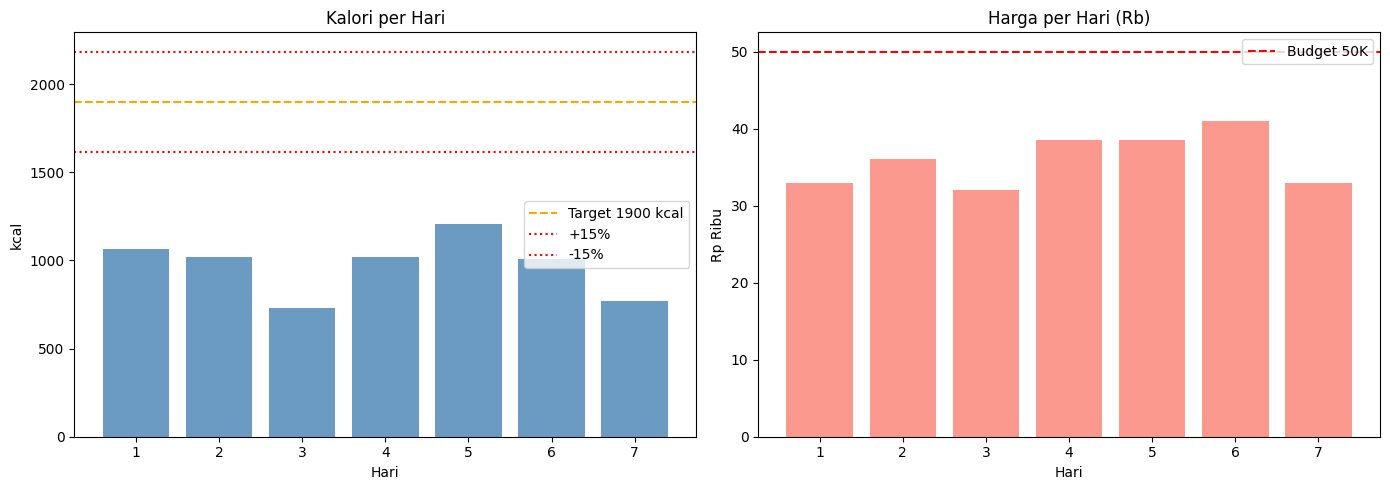

In [19]:
# ── 5. Visualisasi ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

days = [d['day'] for d in plan_7day]
cals = [d['total_calories'] for d in plan_7day]
prices = [d['total_price_idr']/1000 for d in plan_7day]

axes[0].bar(days, cals, color='steelblue', alpha=0.8)
axes[0].axhline(TARGET_CALORIES, color='orange', linestyle='--', label=f'Target {TARGET_CALORIES} kcal')
axes[0].axhline(TARGET_CALORIES*1.15, color='red', linestyle=':', label='+15%')
axes[0].axhline(TARGET_CALORIES*0.85, color='red', linestyle=':', label='-15%')
axes[0].set_title('Kalori per Hari')
axes[0].set_xlabel('Hari'); axes[0].set_ylabel('kcal')
axes[0].legend()

axes[1].bar(days, prices, color='salmon', alpha=0.8)
axes[1].axhline(BUDGET_IDR/1000, color='red', linestyle='--', label='Budget 50K')
axes[1].set_title('Harga per Hari (Rb)')
axes[1].set_xlabel('Hari'); axes[1].set_ylabel('Rp Ribu')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/validation/calories_budget.png', dpi=150)
plt.show()

In [20]:
# ── 6. Save Validation Report ──
report = {
    'calorie_deviation_avg_pct': round(float(np.mean(cal_devs)), 2),
    'calorie_deviation_max_pct': round(float(np.max(cal_devs)), 2),
    'budget_compliance':         f'{sum(budget_ok)}/7',
    'macro_balance_pass':        f'{sum(macro_ok)}/7',
    'diversity_score':           round(float(diversity), 4),
    'medical_match_rate':        round(float(match_rate), 4) if match_rate else 'N/A',
    'pass': {
        'calorie': bool(np.max(cal_devs) <= 15),
        'budget':  bool(all(budget_ok)),
        'macro':   bool(all(macro_ok)),
        'diversity': bool(diversity >= 0.85),
        'medical': bool(match_rate >= 0.80) if match_rate else None,
    },
}
with open('output/validation/validation_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print('✅ Validation selesai.')
print(json.dumps(report, indent=2))

✅ Validation selesai.
{
  "calorie_deviation_avg_pct": 48.74,
  "calorie_deviation_max_pct": 61.63,
  "budget_compliance": "7/7",
  "macro_balance_pass": "3/7",
  "diversity_score": 0.92,
  "medical_match_rate": 1.0,
  "pass": {
    "calorie": false,
    "budget": true,
    "macro": false,
    "diversity": true,
    "medical": true
  }
}
